## Introduction to NetworkX

![](img/NetworkX.jpg)

---

### Get prepared

#### Required installations

tbd

#### Imports

In [1]:
import networkx as nx
import pandas as pd
pd.options.display.max_rows = 400
import matplotlib.pyplot as plt

---

### The *Game of Thrones* dataset

#### *GoT* Network

The network data that we're going to use in this lesson is taken from Andrew Beveridge and Jie Shan's paper, ["Network of Thrones."](https://www.maa.org/sites/default/files/pdf/Mathhorizons/NetworkofThrones%20%281%29.pdf)

These researchers calculated how many times each Game of Thrones character appeared within 15 words of another character in *A Storm of Swords*, the third book in the series.

| Network Element      | GOT |         
| :-------------: |:-------------:| 
| Node    | GOT character | 
| Edge     | Mutually mentioned within 15 words      | 
| Float | Decimal Numbers      |  
| Boolean | True/False     |   


For example, the following sentence counts as an "edge" or connection between Jon Snow and Sam Tarly:

> "It was the bastard **Jon Snow** who had taken that from him, him and his fat friend **Sam Tarly**."

> "Lucky it might be, and red it certainly was, but **Ygritte**’s hair was such a tangle that **Jon** was tempted to ask her if she only brushed it at the changing of the seasons."

> "**Arya** gave **Gendry** a sideways look. *He said it with me, like **Jon** used to do, back in Winterfell.* She missed **Jon Snow** the most of all her brothers.""

#### Get data

In [2]:
got_df = pd.read_csv('./datasets/data/got-edges.csv')
got_df.head()

,Source,Target,Weight
0,Aemon,Grenn,5
1,Aemon,Samwell,31
2,Aerys,Jaime,18
3,Aerys,Robert,6
4,Aerys,Tyrion,5


---

### Simple graph exploration

#### Create a Network From a Pandas DataFrame

In [16]:
G = nx.from_pandas_edgelist(got_df, 'Source', 'Target', 'Weight')
print(G)
print(list(G.edges(data=True))[:5])  # show first 5 edges with attributes}

Graph with 107 nodes and 352 edges
[('Aemon', 'Grenn', {'Weight': 5}), ('Aemon', 'Samwell', {'Weight': 31}), ('Aemon', 'Jon', {'Weight': 30}), ('Aemon', 'Robert', {'Weight': 4}), ('Aemon', 'Stannis', {'Weight': 4})]


#### Drawing the first GoT graph

plt.figure(figsize=(1,1)) would create an inch-by-inch image, which would be 80-by-80 pixels if you stick with the default dpi value.

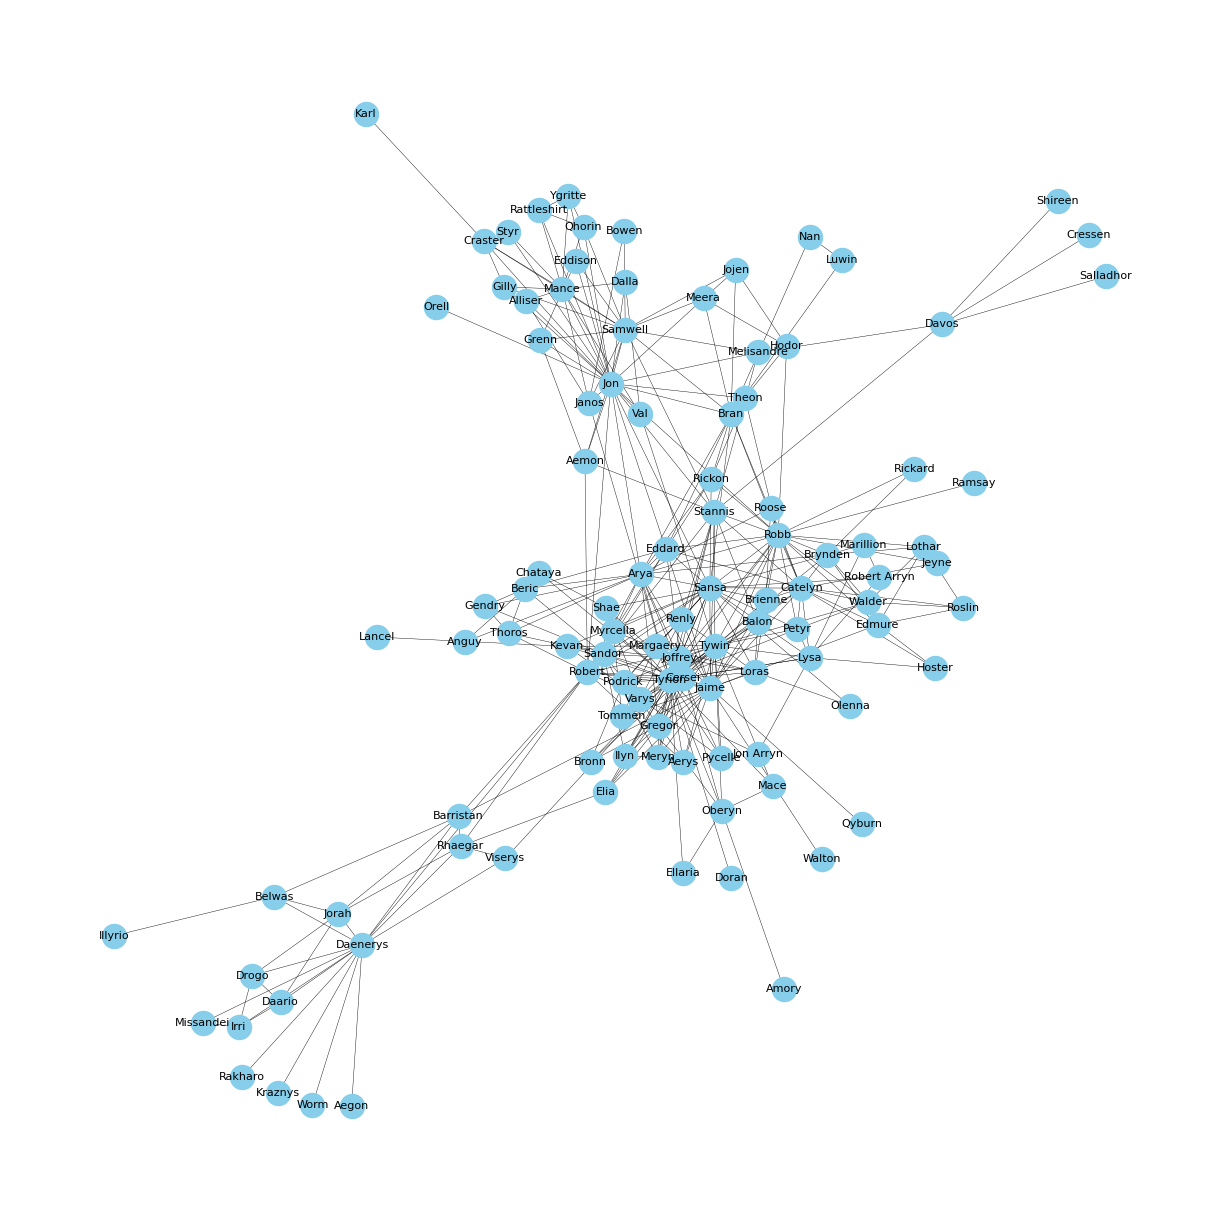

In [4]:
plt.figure(figsize=(12,12))
nx.draw(G, with_labels=True, node_color='skyblue', width=.3, font_size=8)
plt.show()

#### Calculate node degree

Make the degree values a `dict`ionary, then add it as a network "attribute" with `networkx.set_node_attributes()`

In [9]:
degrees = dict(nx.degree(G))
nx.set_node_attributes(G, name='degree', values=degrees)

Now, we can write things like:

In [10]:
for n, attr in list(G.nodes(data=True))[0:5]:
    print(f"{n} {attr}")

Aemon {'degree': 5}
Grenn {'degree': 4}
Samwell {'degree': 15}
Aerys {'degree': 4}
Jaime {'degree': 24}


Additionally, we can see the attributes of individual nodes:

In [11]:
G.nodes["Grenn"]

{'degree': 4}

Make a Pandas dataframe from the degree data `G.nodes(data='degree')`, then sort from highest to lowest

In [13]:
degree_df = pd.DataFrame(G.nodes(data='degree'), columns=['node', 'degree'])
degree_df = degree_df.sort_values(by='degree', ascending=False)
degree_df[:10]

,node,degree
6,Tyrion,36
21,Jon,26
50,Sansa,26
48,Robb,25
4,Jaime,24
7,Tywin,22
17,Cersei,20
12,Arya,19
42,Catelyn,18
20,Joffrey,18


Plot the nodes with the highest degree values

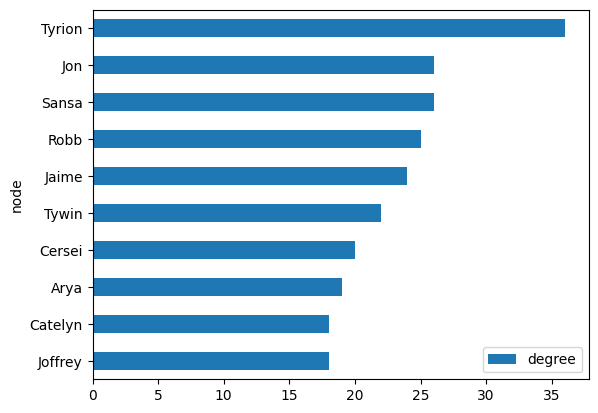

In [14]:
num_nodes_to_inspect = 10
degree_df[:num_nodes_to_inspect].plot(x='node', y='degree', kind='barh').invert_yaxis()

#### Calculate Weighted Degree

Who has the most number of connections in the network (if you factor in edge weight)?

In [17]:
nx.degree(G, weight='Weight')

DegreeView({'Aemon': 74, 'Grenn': 81, 'Samwell': 282, 'Aerys': 37, 'Jaime': 372, 'Robert': 128, 'Tyrion': 551, 'Tywin': 204, 'Alliser': 29, 'Mance': 160, 'Amory': 5, 'Oberyn': 76, 'Arya': 269, 'Anguy': 15, 'Beric': 75, 'Bran': 344, 'Brynden': 55, 'Cersei': 226, 'Gendry': 59, 'Gregor': 117, 'Joffrey': 255, 'Jon': 442, 'Rickon': 81, 'Roose': 17, 'Sandor': 137, 'Thoros': 60, 'Balon': 29, 'Loras': 76, 'Belwas': 67, 'Barristan': 63, 'Illyrio': 10, 'Hodor': 177, 'Jojen': 125, 'Luwin': 8, 'Meera': 139, 'Nan': 18, 'Theon': 38, 'Brienne': 122, 'Bronn': 59, 'Podrick': 64, 'Lothar': 34, 'Walder': 87, 'Catelyn': 184, 'Edmure': 98, 'Hoster': 24, 'Jeyne': 28, 'Lysa': 108, 'Petyr': 89, 'Robb': 342, 'Roslin': 32, 'Sansa': 383, 'Stannis': 146, 'Elia': 29, 'Ilyn': 32, 'Meryn': 47, 'Pycelle': 24, 'Shae': 45, 'Varys': 49, 'Craster': 75, 'Karl': 6, 'Daario': 30, 'Drogo': 35, 'Irri': 33, 'Daenerys': 232, 'Aegon': 8, 'Jorah': 89, 'Kraznys': 10, 'Missandei': 30, 'Rakharo': 7, 'Rhaegar': 42, 'Viserys': 19, 'Wo

Make the weighted degree values a `dict`ionary, then add it as a network "attribute" with `networkx.set_node_attributes()`

In [18]:
weighted_degrees = dict(nx.degree(G, weight='Weight'))
nx.set_node_attributes(G, name='weighted_degree', values=weighted_degrees)

Make a Pandas dataframe from the degree data `G.nodes(data='weighted_degree')`, then sort from highest to lowest

In [20]:
weighted_degree_df = pd.DataFrame(G.nodes(data='weighted_degree'), columns=['node', 'weighted_degree'])
weighted_degree_df = weighted_degree_df.sort_values(by='weighted_degree', ascending=False)
weighted_degree_df[:10]

,node,weighted_degree
6,Tyrion,551
21,Jon,442
50,Sansa,383
4,Jaime,372
15,Bran,344
48,Robb,342
2,Samwell,282
12,Arya,269
20,Joffrey,255
63,Daenerys,232


Plot the nodes with the highest weighted degree values

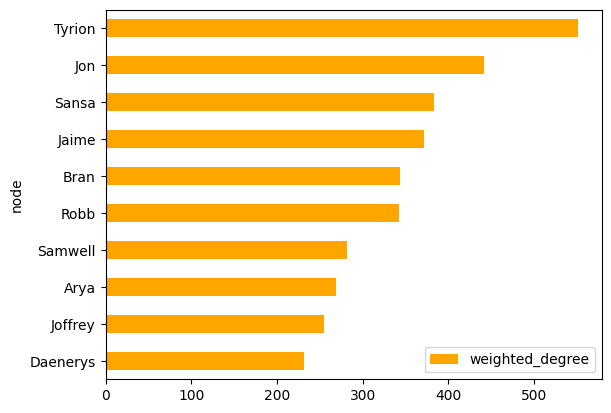

In [21]:
num_nodes_to_inspect = 10
weighted_degree_df[:num_nodes_to_inspect].plot(x='node', y='weighted_degree', color='orange', kind='barh').invert_yaxis()

#### Calculate Betweenness Centrality Scores

In graph theory, betweenness centrality is a measure of centrality in a graph based on shortest paths. 
In short: How many shortest paths pass a node?
More precise: What is the fraction of a graph's shortest paths that pass a certain node?

In [ ]:
betweenness_centrality = nx.betweenness_centrality(G)

Add `betweenness_centrality` (which is already a dictionary) as a node attribute with `networkx.set_node_attributes()`

In [25]:
nx.set_node_attributes(G, name='betweenness', values=nx.betweenness_centrality(G))

Make a Pandas dataframe from the betweenness data `G.nodes(data='betweenness')`, then sort from highest to lowest

In [26]:
betweenness_df = pd.DataFrame(G.nodes(data='betweenness'), columns=['node', 'betweenness'])
betweenness_df = betweenness_df.sort_values(by='betweenness', ascending=False)
betweenness_df[:10]

,node,betweenness
21,Jon,0.229965
5,Robert,0.209452
6,Tyrion,0.197913
63,Daenerys,0.157203
48,Robb,0.126964
50,Sansa,0.126720
51,Stannis,0.102700
4,Jaime,0.099943
12,Arya,0.079607
7,Tywin,0.065538


Plot the nodes with the highest betweenness centrality scores

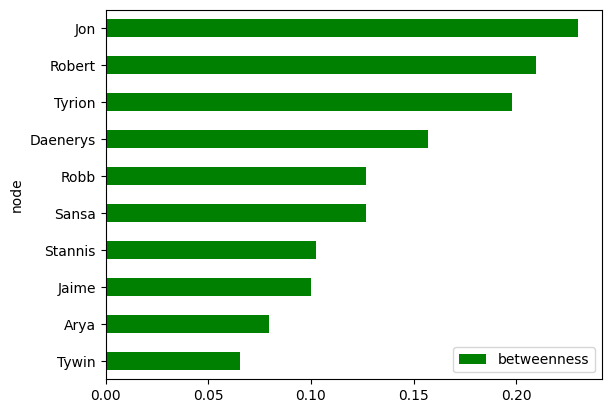

In [27]:
num_nodes_to_inspect = 10
betweenness_df[:num_nodes_to_inspect].plot(x='node', y='betweenness', color='green', kind='barh').invert_yaxis()